In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import time
import itertools
from joblib import Parallel, delayed

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Data

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_GROWTH_SURPRISE_CRASH_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df = df[~df['symbol'].isin(['WEN', 'SVU', 'FSLR'])].copy()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

#df = df[df['bull_market']==1]

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

2026-03-21 12:44:46.551 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/21 12:44:47 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/21 12:44:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d6cde6f1-c23b-43f4-8fe7-9abef9dbb34e;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 89ms :: artifacts dl 5ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


:: retrieving :: org.apache.spark#spark-submit-parent-d6cde6f1-c23b-43f4-8fe7-9abef9dbb34e
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/4ms)
26/03/21 12:44:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 12:44:53 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/21 12:44:53 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/21 12:44:53 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
2026-03-21 12:44:53.936 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (545137, 166)
Years: 1993


In [3]:
class OHLCResampler:
    def __init__(self, data, date_col="Date", ticker_col="Ticker"):
        self.data = data.copy()
        self.date_col = date_col
        self.ticker_col = ticker_col

        # S'assurer que la colonne de date est bien en datetime
        self.data[date_col] = pd.to_datetime(self.data[date_col])
        self.data.set_index(date_col, inplace=True)

    def resample(self, period='W'):
        grouped = self.data.groupby(self.ticker_col)

        resampled = grouped.resample(period).agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).reset_index()

        return resampled

# Backtest

## Top n Portfolio

In [4]:
import pandas as pd
import numpy as np

def generate_top_n_portfolio_ps_ratio_Momentum(
    df, 
    top_n=10, 
    rebalance_freq='W',
    momentum=52,          # 👈 Période pour calculer le momentum (ex: 52 semaines = 1 an)
    pricetobook=1.5       # 👈 Seuil maximum autorisé pour le Price-to-Sales
):
    """
    Sélectionne le Top N basé sur le MOMENTUM, parmi un univers filtré par la VALUE.
    """
    # ==========================================
    # 📈 1. PRÉPARATION DES DONNÉES ACTIONS
    # ==========================================
    # On isole les actions (on ignore le S&P 500 s'il est présent)
    data = df[df['symbol'] != '^GSPC'][['symbol', 'date', 'adjClose', 'priceToBookRatio']].copy()
    data = data.sort_values(['symbol', 'date'])

    # --- 2. Calcul du Rendement Futur ET du Momentum ---
    data['NextReturn'] = data.groupby('symbol')['adjClose'].shift(-1) / data['adjClose'] - 1
    
    # 🚀 NOUVEAU : Calcul du Momentum (Rendement sur la période passée)
    data['Momentum'] = data.groupby('symbol')['adjClose'].pct_change(periods=momentum)

    # --- 3. Gestion des dates de rebalancement ---
    if rebalance_freq == 'W':
        data['is_rebalance_date'] = True
    else:
        if rebalance_freq == 'M':
            data['Period'] = data['date'].dt.to_period('M')
        elif rebalance_freq == 'Q':
            data['Period'] = data['date'].dt.to_period('Q')
        elif rebalance_freq == '6M':
            data['Period'] = data['date'].dt.year.astype(str) + "H" + np.where(data['date'].dt.month <= 6, '1', '2')
        elif rebalance_freq == 'Y':
            data['Period'] = data['date'].dt.to_period('Y')
            
        rebalance_dates = data.groupby('Period')['date'].transform('max')
        data['is_rebalance_date'] = (data['date'] == rebalance_dates)

    # --- 4. FILTRAGE ET RANKING (Top N) ---
    # On s'assure d'avoir assez d'historique pour le P/S ET le Momentum
    reb_data = data[data['is_rebalance_date']].dropna(subset=['priceToBookRatio', 'Momentum']).copy()
    
    # 🛡️ LE FILTRE VALUE : P/S strictement positif ET inférieur ou égal au seuil exigé
    reb_data = reb_data[(reb_data['priceToBookRatio'] > 0) & (reb_data['priceToBookRatio'] <= pricetobook)]
    
    # 🚀 LE RANKING MOMENTUM : On classe du plus GRAND au plus PETIT (ascending=False)
    # Les actions avec le Momentum le plus fort obtiennent le Rang 1
    reb_data['Rank'] = reb_data.groupby('date')['Momentum'].rank(method='first', ascending=False)
    
    buys = reb_data[reb_data['Rank'] <= top_n].copy()
    
    # Si le filtre P/S est très strict, il se peut qu'il y ait moins de 'top_n' actions qualifiées.
    # Diviser par top_n garantit que la part manquante restera sagement en Cash.
    buys['Base_Weight'] = 1.0 / top_n

    # --- 5. Intégration et Propagation ---
    data = data.merge(buys[['symbol', 'date', 'Base_Weight']], on=['symbol', 'date'], how='left')
    data.loc[data['is_rebalance_date'] & data['Base_Weight'].isna(), 'Base_Weight'] = 0.0
    data['Base_Weight'] = data.groupby('symbol')['Base_Weight'].ffill().fillna(0.0)

    # ==========================================
    # 🛡️ 6. FINALISATION
    # ==========================================
    data['Target_Weight'] = data['Base_Weight']
    data = data.dropna(subset=['NextReturn'])

    return data

## Vectorized Backtester

In [5]:
def run_vectorized_backtest(data, transaction_cost=0):
    """
    Calcule la performance globale et compte le nombre de trades par semaine.
    """
    data['Weight_Change'] = data.groupby('symbol')['Target_Weight'].diff().fillna(data['Target_Weight'])
    data['Cost'] = data['Weight_Change'].abs() * transaction_cost
    data['Strat_Return'] = data['Target_Weight'] * data['NextReturn']
    
    # 🆕 COMPTAGE DES TRADES
    # On utilise un petit seuil (0.001) pour éviter les bugs de précision des flottants en Python
    data['is_buy'] = (data['Weight_Change'] > 0.001).astype(int)
    data['is_sell'] = (data['Weight_Change'] < -0.001).astype(int)
    
    # Agrégation au niveau du Portefeuille
    port_returns = data.groupby('date')[['Strat_Return', 'Cost']].sum()
    trade_counts = data.groupby('date')[['is_buy', 'is_sell']].sum()
    
    # On fusionne les rendements et le comptage des trades
    port_returns = port_returns.join(trade_counts)
    
    port_returns['Net_Return'] = port_returns['Strat_Return'] - port_returns['Cost']
    port_returns['Capital'] = (1 + port_returns['Net_Return']).cumprod()
    
    return port_returns

## Running only one combination

In [6]:
def run_single_backtest(params, df_source, start_date, end_date):
    top_n, reb_freq, momentum, pricetobook = params

    default_output = {
        "Top_N": top_n,
        "Rebalance": reb_freq,
        "Momentum": momentum,
        "PriceToBook": pricetobook,
        "Total Return": np.nan, 
        "CAGR": np.nan,
        "Calmar Ratio": np.nan,
        "Max Drawdown": np.nan,
        "Sharpe Ratio": np.nan, 
        "Error": None
    }

    try:
        # Sécurité absolue : on s'assure que les dates sont bien des objets Datetime
        df_source = df_source.copy()
        df_source['date'] = pd.to_datetime(df_source['date'])
        
        full_signals = generate_top_n_portfolio_ps_ratio_Momentum(
            df_source,
            top_n=top_n, 
            rebalance_freq=reb_freq,
            momentum=momentum,
            pricetobook=pricetobook
        )

        mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
        
        # 🛡️ CORRECTION : On ajoute .copy() pour éviter les crashs SettingWithCopyWarning
        backtest_data = full_signals.loc[mask].copy()

        if backtest_data.empty:
            default_output["Error"] = "No data in timeframe"
            return default_output

        res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.005)

        total_return = res_df['Capital'].iloc[-1] - 1
        n_years = (res_df.index[-1] - res_df.index[0]).days / 365.25
        cagr = (res_df['Capital'].iloc[-1]) ** (1 / max(1, n_years)) - 1
        
        rolling_max = res_df['Capital'].cummax()
        max_dd = ((res_df['Capital'] - rolling_max) / rolling_max).min()
        
        mean_ret = res_df['Net_Return'].mean()
        std_ret = res_df['Net_Return'].std()
        sharpe = (mean_ret / std_ret) * np.sqrt(52) if std_ret > 0 else 0
        calmar = abs(cagr/max_dd) if max_dd != 0 else 0 # 🛡️ Sécurité division par zéro

        output = default_output.copy()
        output.update({
            "Total Return": total_return, 
            "CAGR": cagr,
            "Calmar Ratio": calmar,
            "Max Drawdown": max_dd, 
            "Sharpe Ratio": sharpe
        })
        return output

    except Exception as e:
        # 🛡️ CORRECTION : On capture l'erreur exacte pour savoir ce qui cloche
        default_output["Error"] = repr(e) 
        return default_output

## Grid Search

In [7]:
def grid_search_execution(df, param_grid, start_date, end_date):
    keys, values = zip(*param_grid.items())
    combinations = [v for v in itertools.product(*values)]

    print(f"🚀 Lancement de la Grid Search sur {len(combinations)} combinaisons...")
    start_time = time.time()

    # Exécution en parallèle sur tous les coeurs du processeur (n_jobs=-1)
    results_list = Parallel(n_jobs=-1)(
        delayed(run_single_backtest)(params, df, start_date, end_date) for params in combinations
    )

    end_time = time.time()
    print(f"✅ Terminé en {end_time - start_time:.2f} secondes.")

    results_df = pd.DataFrame(results_list)
    
    # On affiche les 10 meilleures stratégies triées par Sharpe Ratio
    best_strats = results_df[results_df['Error'].isna()].sort_values(by='Sharpe Ratio', ascending=False)
    return best_strats

## Running Backtest

In [8]:
# Définition de la grille de paramètres (Stock Picking pur)
param_grid = {
    'top_n': [10],         # Portefeuille très concentré vs très diversifié
    'rebalance_freq': ['W', 'M', 'Q', '6M', 'Y'],
    'momentum': [12, 26, 52],
    'pricetobook':[0.1,0.2, 0.3,0.4,0.5, 1, 1.5, 2]
}

# Lancement de la Grid Search
best_strategies_df = grid_search_execution(
    df=df,  # Ton DataFrame source
    param_grid=param_grid,
    start_date='2016-01-01',
    end_date='2026-01-01'
)

🚀 Lancement de la Grid Search sur 120 combinaisons...
✅ Terminé en 17.45 secondes.



🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE ---
Top N: 10 | Rebalance: Y | Momentum: 52 | PriceToBook: 1.0
📥 Téléchargement de l'indice de référence (^GSPC) depuis Yahoo Finance...

📋 --- APERÇU DES 15 DERNIÈRES POSITIONS DU PORTEFEUILLE ---
      date symbol Poids_Alloué Rendement_Réalisé
2025-12-26     BG        10.0%              4.0%
2025-12-26    CFG        10.0%            -0.72%
2025-12-26      C        10.0%            -1.44%
2025-12-26    ALB        10.0%            -4.05%
2025-12-26    BEN        10.0%            -0.25%
2025-12-26    TFC        10.0%            -1.72%
2025-12-26    IVZ        10.0%            -0.07%
2025-12-26     DD        10.0%            -0.92%
2025-12-26     SB        10.0%             0.21%
2025-12-26     WB        10.0%             3.94%
2025-12-19    CFG        10.0%             1.07%
2025-12-19     DD        10.0%              0.0%
2025-12-19    KEY        10.0%             1.01%
2025-12-19    TFC        10.0%             1.05%
2025-12-19   VTRS        

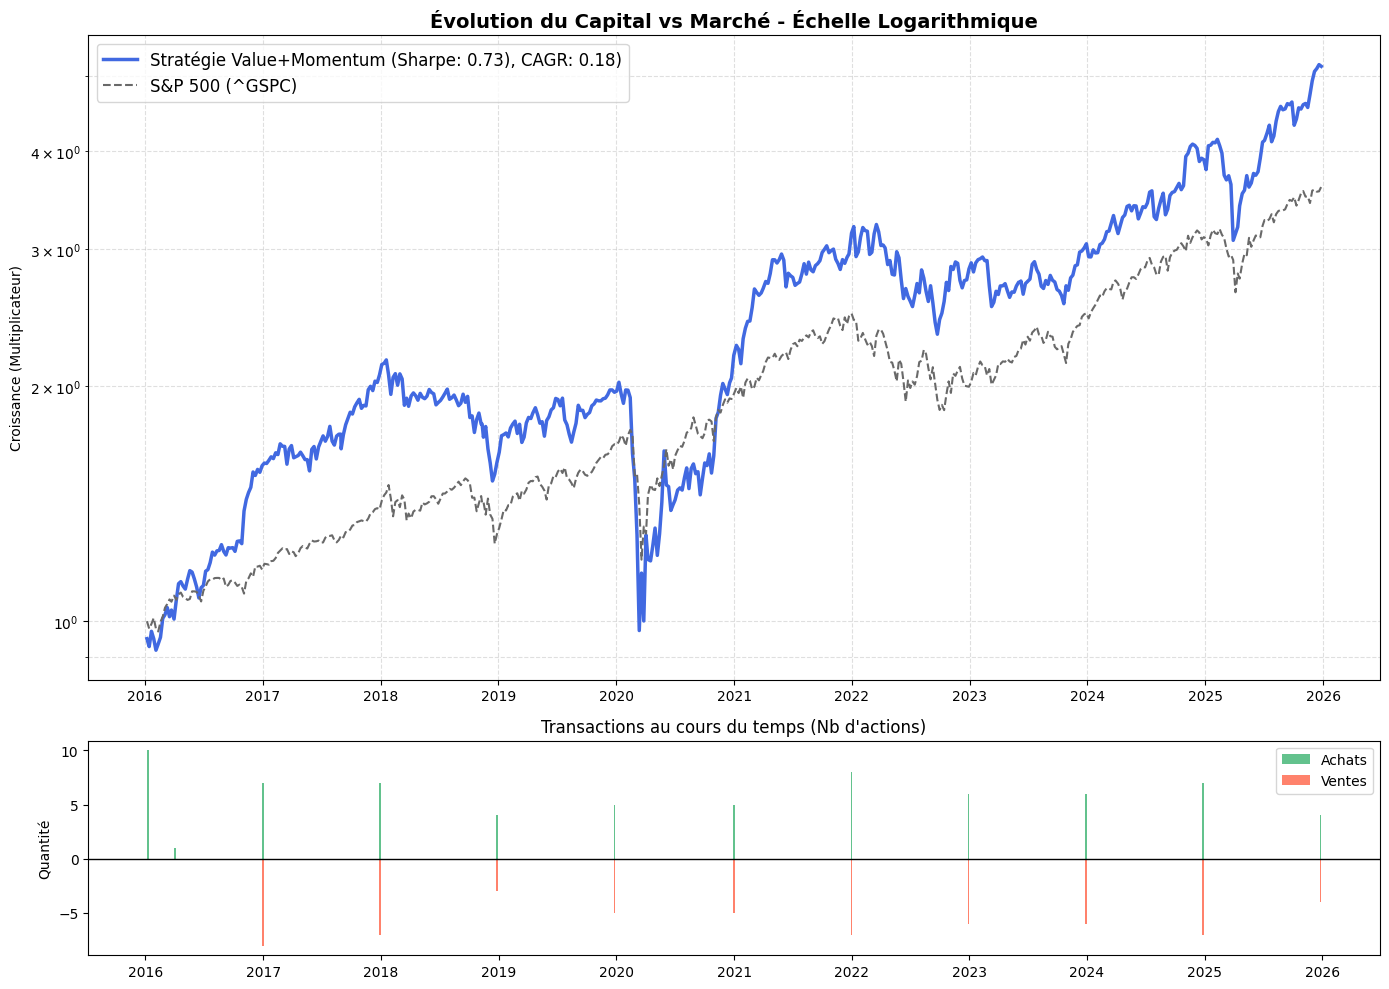

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf  # 👈 NOUVEL IMPORT OBLIGATOIRE

def analyze_best_strategy(best_df, df_source, start_date, end_date):
    if best_df.empty:
        print("❌ Aucune stratégie valide trouvée.")
        return None, None
        
    # 1. Extraction des paramètres de la meilleure ligne
    best_params = best_df.sort_values(by='CAGR', ascending=False).iloc[0]
    print("\n🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE ---")
    print(f"Top N: {best_params['Top_N']} | Rebalance: {best_params['Rebalance']} | Momentum: {best_params['Momentum']} | PriceToBook: {best_params['PriceToBook']}")
    
    # 2. Génération des signaux 
    # 🛠️ CORRECTION : Ajout des variables momentum et pricetosale qui manquaient !
    full_signals = generate_top_n_portfolio_ps_ratio_Momentum(
        df_source, 
        top_n=int(best_params['Top_N']), 
        rebalance_freq=best_params['Rebalance'],
        momentum=int(best_params['Momentum']),
        pricetobook=float(best_params['PriceToBook'])
    )
    
    # Filtrage des dates
    mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
    backtest_data = full_signals.loc[mask].copy()
    
    # 3. Récupération de la Time-Series du Portefeuille
    res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.005)
    
    # ==========================================
    # 📈 AJOUT DU BENCHMARK (YAHOO FINANCE)
    # ==========================================
    print("📥 Téléchargement de l'indice de référence (^GSPC) depuis Yahoo Finance...")
    try:
        # Téléchargement des données sur la période demandée
        gspc_data = yf.download('^GSPC', start=start_date, end=end_date, progress=False)
        
        # Gestion des nouvelles versions de yfinance (MultiIndex)
        if isinstance(gspc_data.columns, pd.MultiIndex):
            gspc_close = gspc_data['Close']['^GSPC']
        else:
            gspc_close = gspc_data['Close']
            
        # Suppression des fuseaux horaires pour éviter les bugs de jointure
        gspc_close.index = pd.to_datetime(gspc_close.index).tz_localize(None)
        
        # On crée un index d'alignement pour coller EXACTEMENT aux dates de ta stratégie
        aligned_gspc = pd.DataFrame(index=pd.to_datetime(res_df.index).tz_localize(None))
        
        # On ramène le dernier prix connu du S&P 500 (ffill = forward fill) pour gérer les week-ends
        aligned_gspc['GSPC_Price'] = gspc_close.reindex(aligned_gspc.index, method='ffill')
        
        # Si la toute première date tombe un week-end, on prend le prix du jour suivant (bfill)
        aligned_gspc['GSPC_Price'] = aligned_gspc['GSPC_Price'].bfill()
        
        # 🚀 Calcul du portefeuille Benchmark (Capital de départ = 1.0)
        # On divise simplement le prix du jour par le tout premier prix !
        res_df['GSPC_Capital'] = aligned_gspc['GSPC_Price'] / aligned_gspc['GSPC_Price'].iloc[0]
        
    except Exception as e:
        print(f"⚠️ Erreur lors du téléchargement du Benchmark : {e}")
        res_df['GSPC_Capital'] = 1.0 # Ligne plate en cas de coupure internet

    # ==========================================
    # 📋 CRÉATION DU TABLEAU DES ACTIONS DÉTENUES
    # ==========================================
    holdings = backtest_data[backtest_data['Target_Weight'] > 0].copy()
    holdings = holdings[['date', 'symbol', 'Target_Weight', 'NextReturn']]
    holdings.rename(columns={'Target_Weight': 'Poids_Alloué', 'NextReturn': 'Rendement_Réalisé'}, inplace=True)
    
    print("\n📋 --- APERÇU DES 15 DERNIÈRES POSITIONS DU PORTEFEUILLE ---")
    display_holdings = holdings.sort_values(by='date', ascending=False).head(15).copy()
    display_holdings['Poids_Alloué'] = (display_holdings['Poids_Alloué'] * 100).round(2).astype(str) + '%'
    display_holdings['Rendement_Réalisé'] = (display_holdings['Rendement_Réalisé'] * 100).round(2).astype(str) + '%'
    print(display_holdings.to_string(index=False))

    # 4. Affichage des statistiques de trading
    print(f"\n📊 --- STATISTIQUES DE TRADING ---")
    print(f"Moyenne d'actions achetées au rebalancement : {res_df['is_buy'].mean():.2f}")
    print(f"Moyenne d'actions vendues au rebalancement : {res_df['is_sell'].mean():.2f}")
    
    # 5. Graphiques
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    ax1.plot(res_df.index, res_df['Capital'], color='royalblue', linewidth=2.5, label=f"Stratégie Value+Momentum (Sharpe: {best_params['Sharpe Ratio']:.2f}), CAGR: {best_params['CAGR']:.2f})")
    ax1.plot(res_df.index, res_df['GSPC_Capital'], color='dimgray', linewidth=1.5, linestyle='--', label="S&P 500 (^GSPC)")
    ax1.set_yscale('log')
    ax1.set_title(f"Évolution du Capital vs Marché - Échelle Logarithmique", fontsize=14, fontweight='bold')
    ax1.set_ylabel('Croissance (Multiplicateur)')
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper left', fontsize=12)
    
    ax2.bar(res_df.index, res_df['is_buy'], color='mediumseagreen', width=5, alpha=0.8, label='Achats')
    ax2.bar(res_df.index, -res_df['is_sell'], color='tomato', width=5, alpha=0.8, label='Ventes')
    ax2.set_title("Transactions au cours du temps (Nb d'actions)", fontsize=12)
    ax2.set_ylabel('Quantité')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return res_df, holdings

# ==========================================
# 🚀 Lancement de l'analyse
# ==========================================
portfolio_stats, all_trades_history = analyze_best_strategy(best_strategies_df, df, start_date='2016-01-01', end_date='2026-01-01')

In [10]:
all_trades_history.sort_values(by='Rendement_Réalisé', ascending=False).head(50)

,date,symbol,Poids_Alloué,Rendement_Réalisé
117137,2020-04-03,COF,0.1,0.422240
429692,2020-04-03,RF,0.1,0.364501
204869,2020-03-20,FITB,0.1,0.328740
21199,2020-03-20,AIG,0.1,0.326494
204871,2020-04-03,FITB,0.1,0.325581
98220,2020-04-03,CFG,0.1,0.304549
21201,2020-04-03,AIG,0.1,0.296653
333215,2020-04-03,MET,0.1,0.279295
272239,2022-11-04,IVZ,0.1,0.271503
333213,2020-03-20,MET,0.1,0.265899


In [11]:
best_strategies_df.sort_values('CAGR', ascending=False).head(20)

,Top_N,Rebalance,Momentum,PriceToBook,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
117,10,Y,52,1.0,4.142742,0.178593,0.324673,-0.550068,0.726535,None
118,10,Y,52,1.5,3.133039,0.153025,0.342236,-0.447132,0.669796,None
87,10,6M,26,2.0,3.059534,0.150950,0.402975,-0.374590,0.739057,None
102,10,Y,12,1.5,3.018153,0.149768,0.281347,-0.532324,0.649047,None
101,10,Y,12,1.0,2.936772,0.147409,0.259753,-0.567499,0.640138,None
111,10,Y,26,2.0,2.920023,0.146919,0.401406,-0.366010,0.737507,None
110,10,Y,26,1.5,2.814761,0.143790,0.314147,-0.457717,0.677999,None
70,10,Q,52,1.5,2.755405,0.141992,0.255682,-0.555345,0.662587,None
63,10,Q,26,2.0,2.708559,0.140554,0.333488,-0.421467,0.691849,None
84,10,6M,26,0.5,2.628315,0.138054,1.333885,-0.103497,1.066662,None


In [12]:
best_strategies_df.sort_values('Sharpe Ratio', ascending=False).head(20)

,Top_N,Rebalance,Momentum,PriceToBook,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
84,10,6M,26,0.5,2.628315,0.138054,1.333885,-0.103497,1.066662,None
92,10,6M,52,0.5,2.550656,0.135585,1.310039,-0.103497,1.059568,None
76,10,6M,12,0.5,2.567023,0.136110,0.821039,-0.165777,0.972182,None
60,10,Q,26,0.5,2.156626,0.122261,0.562937,-0.217183,0.910792,None
68,10,Q,52,0.5,1.997622,0.116455,0.536208,-0.217183,0.878606,None
100,10,Y,12,0.5,1.404004,0.092004,1.146924,-0.080218,0.853292,None
108,10,Y,26,0.5,1.311847,0.087729,1.093634,-0.080218,0.826375,None
116,10,Y,52,0.5,1.311847,0.087729,1.093634,-0.080218,0.826375,None
52,10,Q,12,0.5,1.855654,0.111033,0.511242,-0.217183,0.818235,None
82,10,6M,26,0.3,0.440343,0.037292,0.409221,-0.091129,0.764602,None


In [13]:
all_trades_history.sort_values(by='date', ascending=False).head(50)

,date,symbol,Poids_Alloué,Rendement_Réalisé
70221,2025-12-26,BG,0.1,0.039968
98519,2025-12-26,CFG,0.1,-0.007238
83953,2025-12-26,C,0.1,-0.014357
25531,2025-12-26,ALB,0.1,-0.040500
68456,2025-12-26,BEN,0.1,-0.002515
477219,2025-12-26,TFC,0.1,-0.017166
272403,2025-12-26,IVZ,0.1,-0.000748
140477,2025-12-26,DD,0.1,-0.009248
440862,2025-12-26,SB,0.1,0.002092
518941,2025-12-26,WB,0.1,0.039448


26/03/21 16:29:50 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE